<h1>Analisis actividad 10: Jogging</h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import seaborn as sns


In [2]:
actividad = 10

In [3]:
actividades = {
    1: "Standing still",
    2: "Sitting and relaxing",
    3: "Lying down",
    4: "Walking",
    5: "Climbing stairs",
    6: "Waist bends forward",
    7: "Frontal elevation of arms",
    8: "Knees bending",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jump front & back"
}

<h1>Carga de Dataset</h1>

In [4]:

import glob
import pandas as pd
import re

# Busca todos los archivos
files = glob.glob(r"../DataSets/MHEALTHDATASET/mHealth_subject*.log")

dfs = []

for file in files:
    
    # Extraer número de sujeto desde el nombre del archivo
    subject_id = int(re.search(r"subject(\d+)", file).group(1))
    
    # Leer archivo
    df = pd.read_csv(file, sep='\t', header=None)
    
    # Agregar columna subject_id
    df["subject_id"] = subject_id
    
    dfs.append(df)

# Unir todos
MHEALTHDATASET = pd.concat(dfs, ignore_index=True)

# Asignar nombres de columnas
MHEALTHDATASET.columns = [  
    # Chest sensor
    "chest_acc_x",
    "chest_acc_y",
    "chest_acc_z",
    "ecg_1",
    "ecg_2",

    # Left ankle
    "ankle_acc_x",
    "ankle_acc_y",
    "ankle_acc_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",

    # Right lower arm
    "arm_acc_x",
    "arm_acc_y",
    "arm_acc_z",
    "arm_gyro_x",
    "arm_gyro_y",
    "arm_gyro_z",
    "arm_mag_x",
    "arm_mag_y",
    "arm_mag_z",

    # Label
    "activity_label",
    
    # Nuevo
    "subject_id"
]

pd.set_option('display.max_columns', None)


In [5]:
## Filtramos para mostrar la actividad 
DATASET_ACTIVIDAD = MHEALTHDATASET[MHEALTHDATASET['activity_label'] == actividad]

# Le quitamos las etiquetas
DATASET_SENSORES_ACTIVIDAD = DATASET_ACTIVIDAD.drop(columns=['activity_label'])

<h1>Correlación entre los atributos</h1>

In [6]:

DATASET_SENSORES_ACTIVIDAD.corr()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,subject_id
chest_acc_x,1.000000,0.195572,0.360748,0.135866,0.073734,-0.059731,0.096770,-0.068299,-0.014490,-0.153781,0.060925,0.005396,-0.057152,0.018016,0.536344,0.197006,-0.085012,-0.014608,0.014807,-0.042354,0.061831,0.064294,0.005730,0.022551
chest_acc_y,0.195572,1.000000,0.118903,0.034832,-0.041843,0.035061,-0.000922,0.319104,-0.035475,0.159820,-0.174054,-0.143523,-0.092256,0.154565,0.085433,0.450558,0.052672,0.218174,-0.237338,0.040566,-0.151839,-0.077502,0.239237,-0.011720
chest_acc_z,0.360748,0.118903,1.000000,-0.018477,0.001882,-0.030673,0.070303,-0.133212,0.305395,-0.041982,0.087684,0.279459,0.034740,-0.041622,0.156172,0.072490,-0.022057,0.036344,0.193969,0.270501,-0.095370,-0.034623,0.073915,-0.110795
ecg_1,0.135866,0.034832,-0.018477,1.000000,0.708557,0.015485,0.012526,0.007324,0.062271,0.011578,0.081577,0.061507,0.025523,0.000956,-0.085541,-0.077795,-0.045325,-0.022643,0.027591,0.053814,-0.030955,-0.007451,0.070178,0.006180
ecg_2,0.073734,-0.041843,0.001882,0.708557,1.000000,-0.021876,-0.029083,0.023891,0.066286,0.025077,0.030485,0.064592,0.021503,0.028718,-0.122515,-0.050547,-0.024185,-0.042962,-0.031666,0.010856,0.054734,-0.014830,0.022096,0.033978
ankle_acc_x,-0.059731,0.035061,-0.030673,0.015485,-0.021876,1.000000,0.025510,-0.114111,-0.016707,0.027753,0.044382,-0.052154,-0.298788,-0.028891,-0.000574,0.023400,-0.048754,-0.095358,-0.002905,0.003230,-0.039789,-0.020051,-0.004751,0.052036
ankle_acc_y,0.096770,-0.000922,0.070303,0.012526,-0.029083,0.025510,1.000000,-0.222539,-0.001964,-0.000228,0.113922,-0.018291,-0.056370,-0.138422,0.109925,-0.112132,-0.121176,-0.045370,0.096249,0.009022,-0.071217,-0.149744,0.024134,-0.005423
ankle_acc_z,-0.068299,0.319104,-0.133212,0.007324,0.023891,-0.114111,-0.222539,1.000000,-0.030707,0.252733,-0.241089,-0.275939,-0.151469,0.329713,-0.239661,0.443266,0.084315,0.168216,-0.367273,-0.017349,0.107174,0.089440,0.068648,0.032082
ankle_gyro_x,-0.014490,-0.035475,0.305395,0.062271,0.066286,-0.016707,-0.001964,-0.030707,1.000000,-0.387856,0.582762,-0.091253,-0.063715,0.016030,0.005883,-0.008571,0.033639,0.143278,0.511161,0.821152,0.195870,0.068222,-0.163407,-0.357239
ankle_gyro_y,-0.153781,0.159820,-0.041982,0.011578,0.025077,0.027753,-0.000228,0.252733,-0.387856,1.000000,-0.531229,0.211517,0.051788,0.154289,-0.296490,0.176498,-0.085031,0.107323,-0.533001,-0.270574,-0.396048,-0.148972,0.396660,0.240479


<h1>Histograma de la Actividad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

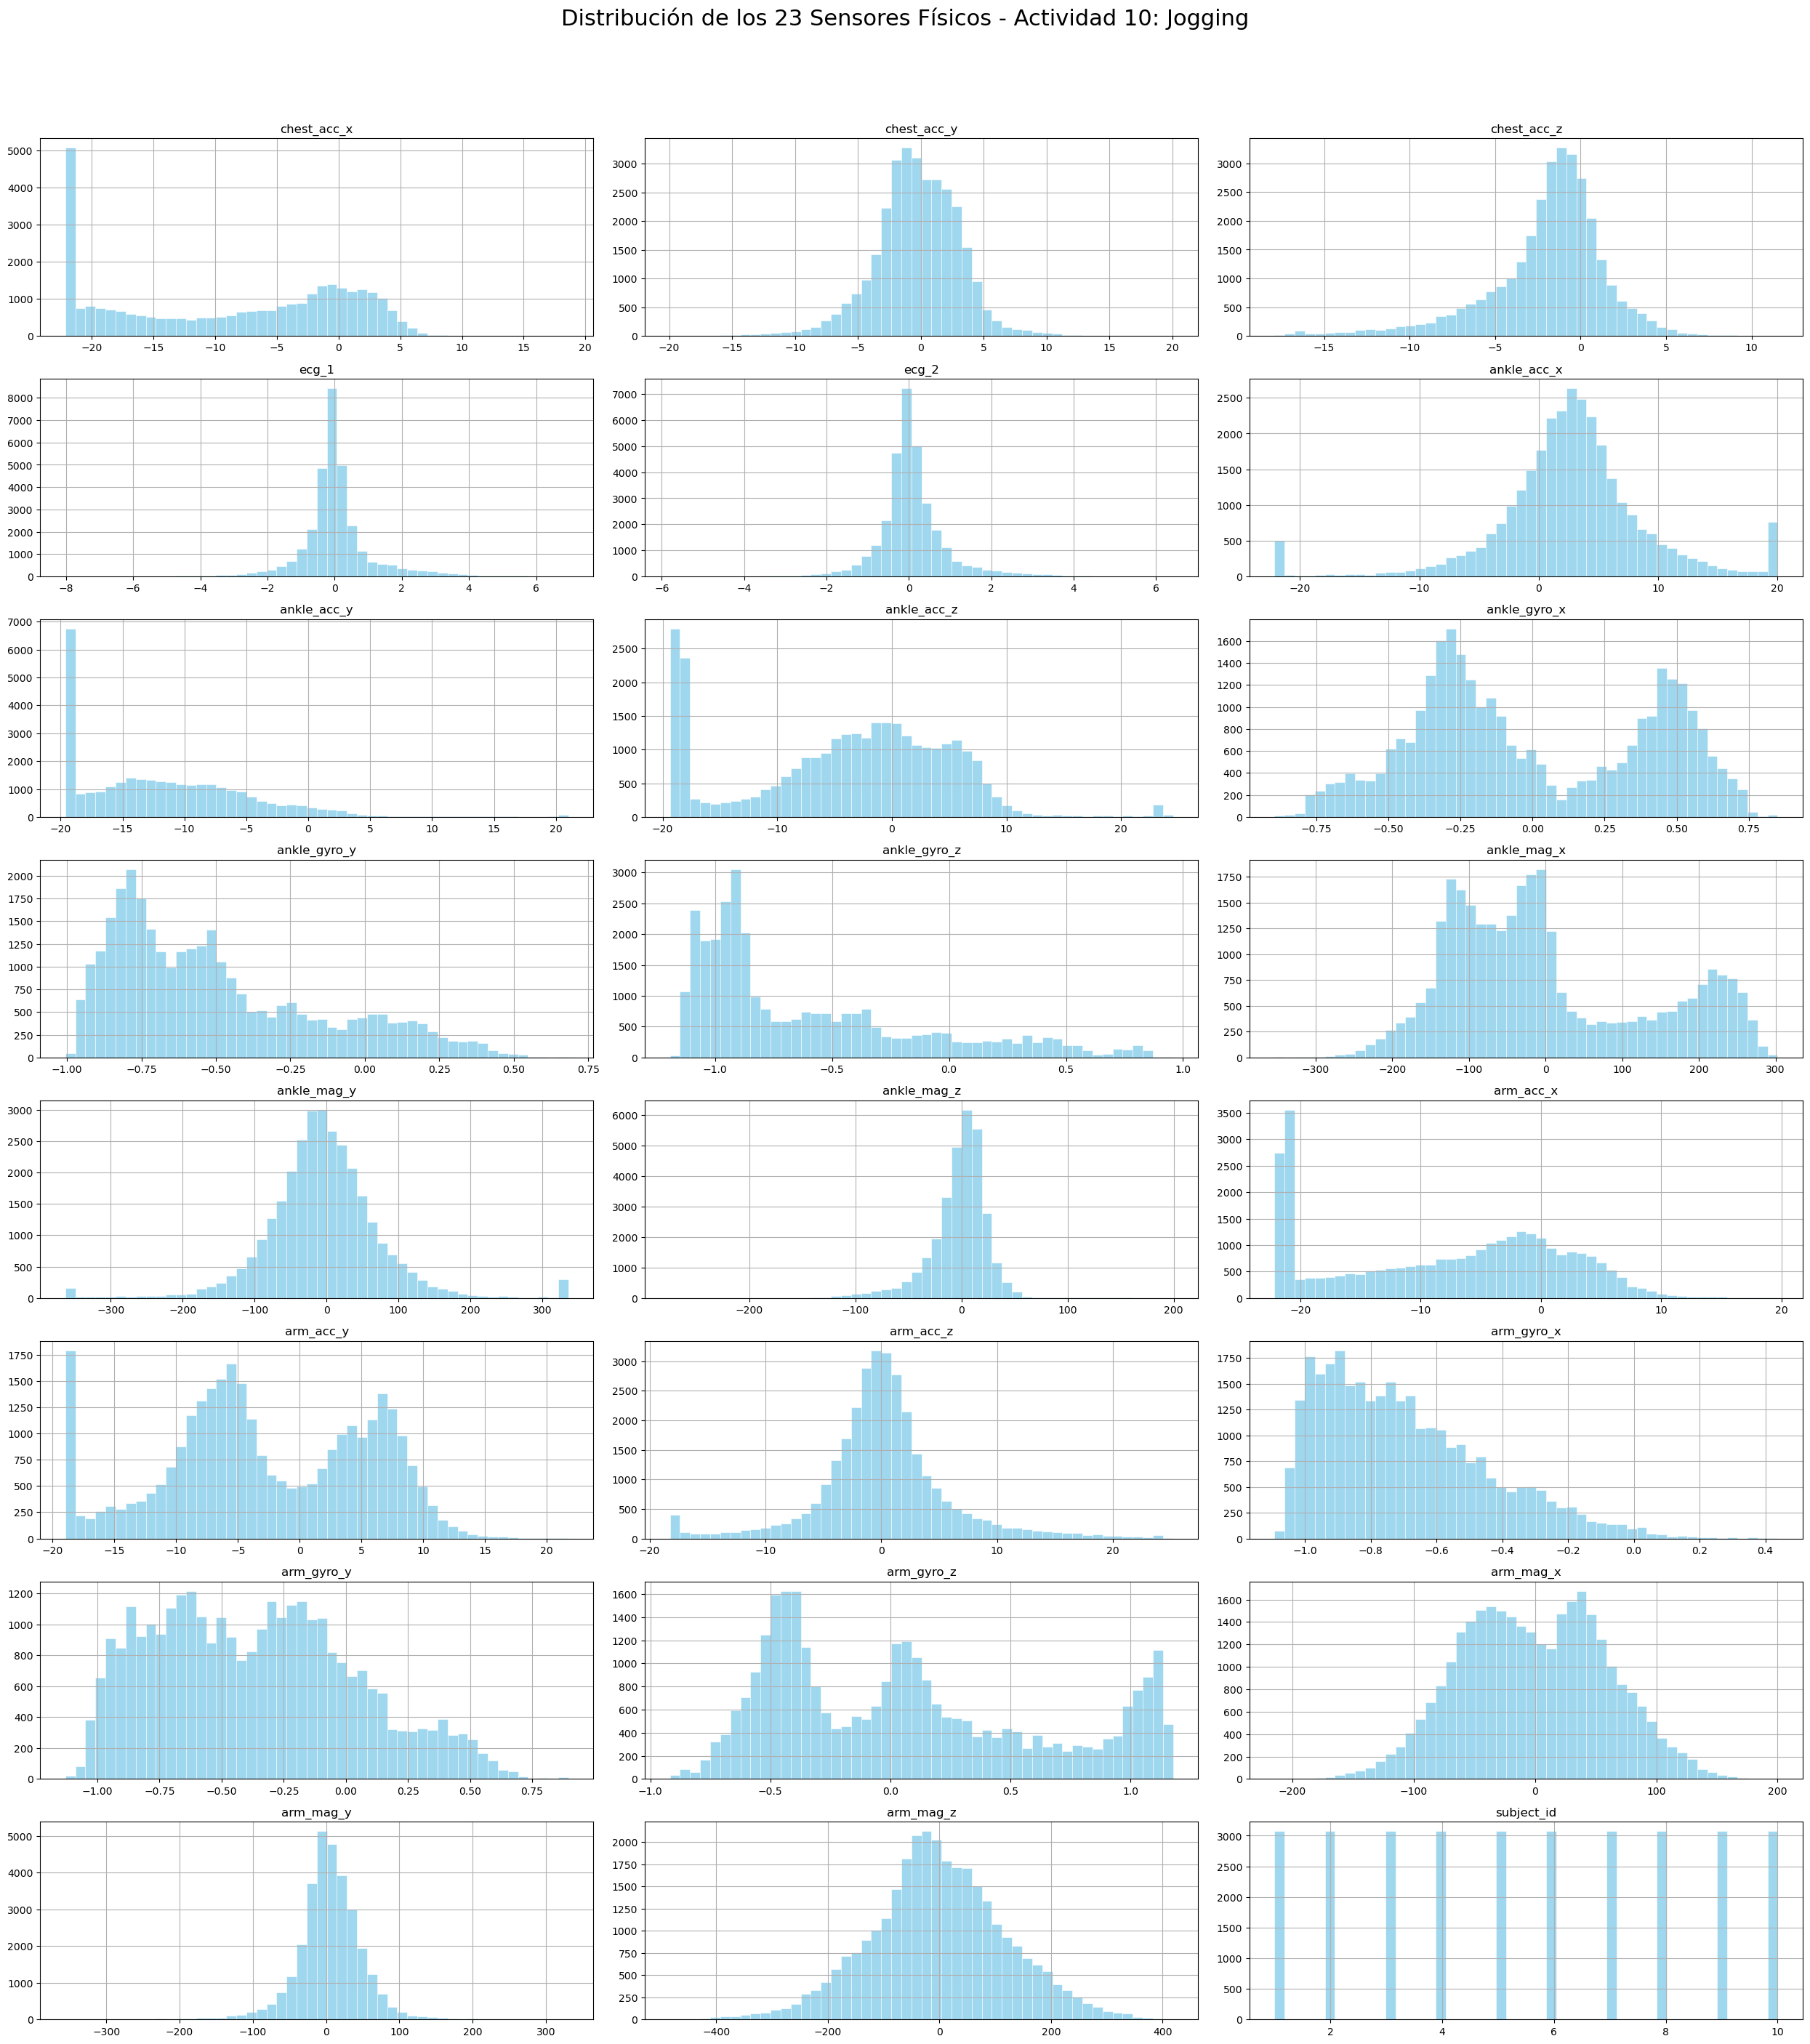

In [7]:


DATASET_SENSORES_ACTIVIDAD.hist(
    bins=50, 
    layout=(15,3),
    figsize=(25, 50), 
    color='skyblue', 
    edgecolor='white', 
    linewidth=0.5,
    alpha=0.8
)

plt.suptitle(f"Distribución de los 23 Sensores Físicos - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Outliers</h1>

In [8]:

outliers_info = []

for col in DATASET_SENSORES_ACTIVIDAD.select_dtypes(include="number").columns:
    
    Q1 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.25)
    Q3 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask_outliers = (DATASET_SENSORES_ACTIVIDAD[col] < lower) | (DATASET_SENSORES_ACTIVIDAD[col] > upper)
    
    total_outliers = mask_outliers.sum()
    percentage = mask_outliers.mean() * 100
    
    outliers_info.append({
        "Sensor": col,
        "Total_Outliers": total_outliers,
        "Porcentaje_Outliers (%)": round(percentage, 2)
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,Sensor,Total_Outliers,Porcentaje_Outliers (%)
0,chest_acc_x,0,0.00
1,chest_acc_y,791,2.57
2,chest_acc_z,1974,6.43
3,ecg_1,4459,14.51
4,ecg_2,3042,9.90
5,ankle_acc_x,2431,7.91
6,ankle_acc_y,274,0.89
7,ankle_acc_z,241,0.78
8,ankle_gyro_x,0,0.00
9,ankle_gyro_y,90,0.29


<h1>Gráfica de densidad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

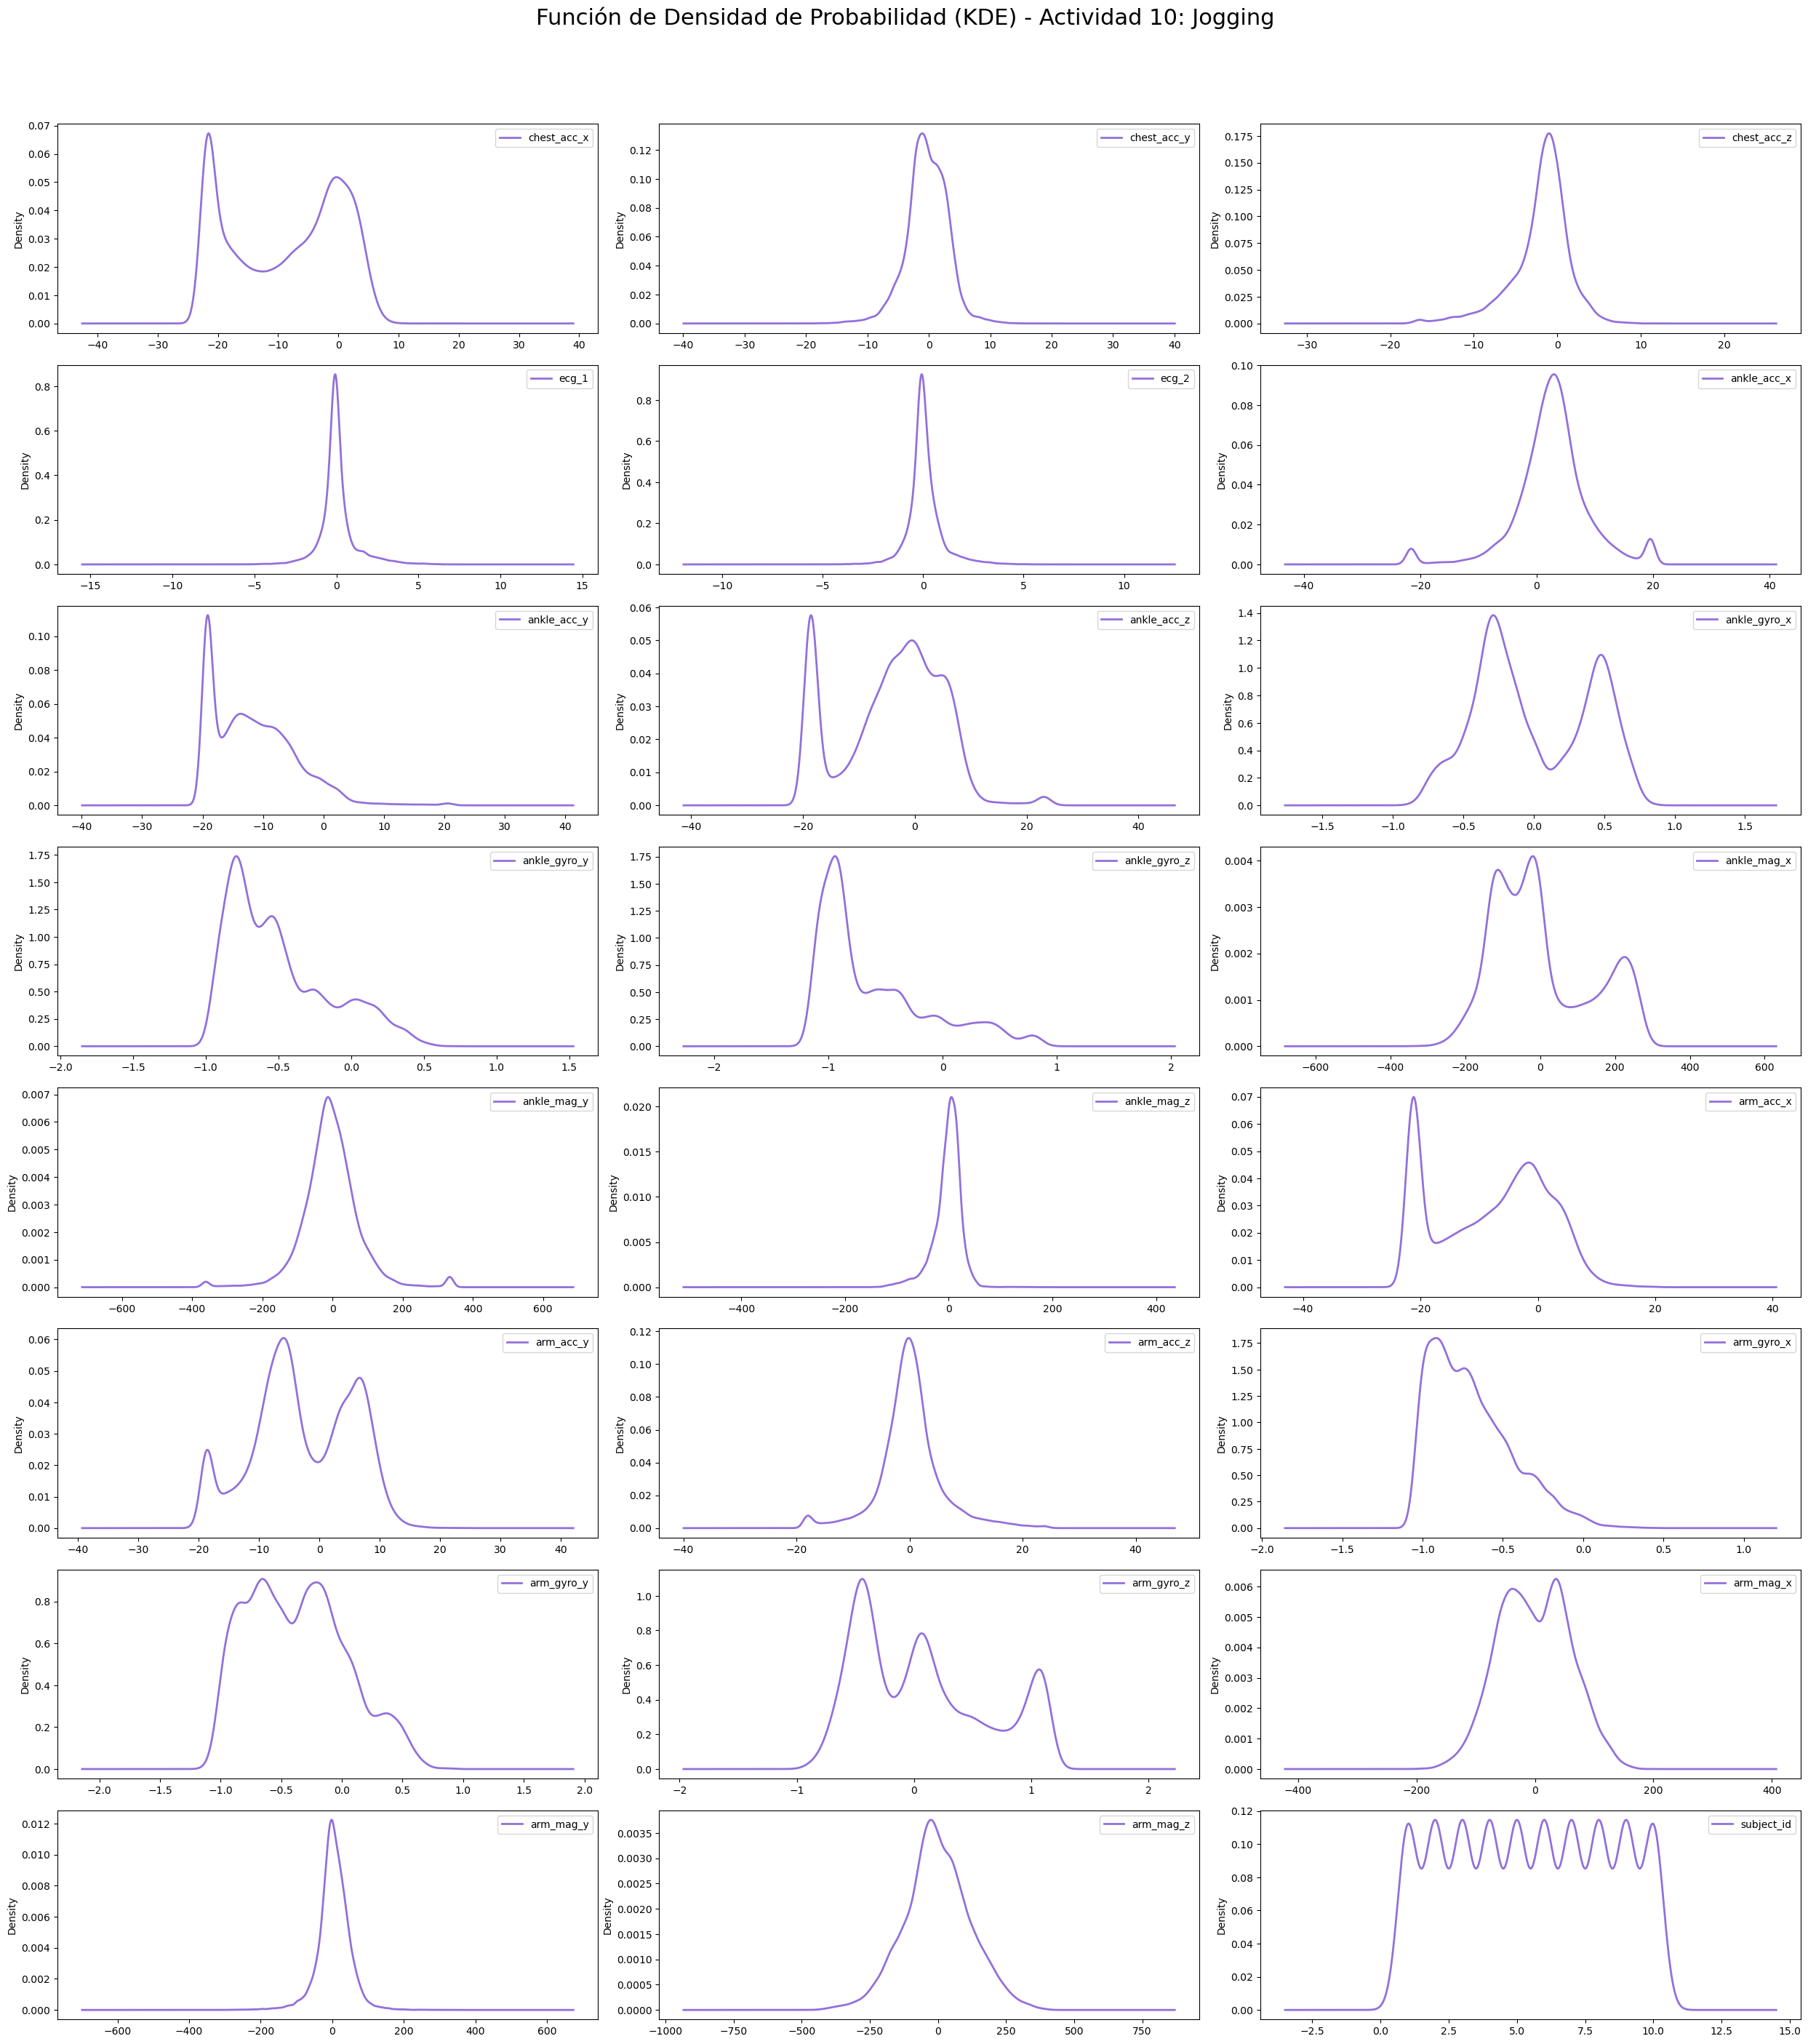

In [9]:
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='density', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(25, 50),
    sharex=False,     
    color='mediumpurple', 
    linewidth=2
)

plt.suptitle(f"Función de Densidad de Probabilidad (KDE) - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Gráfica de cajas y bigotes</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

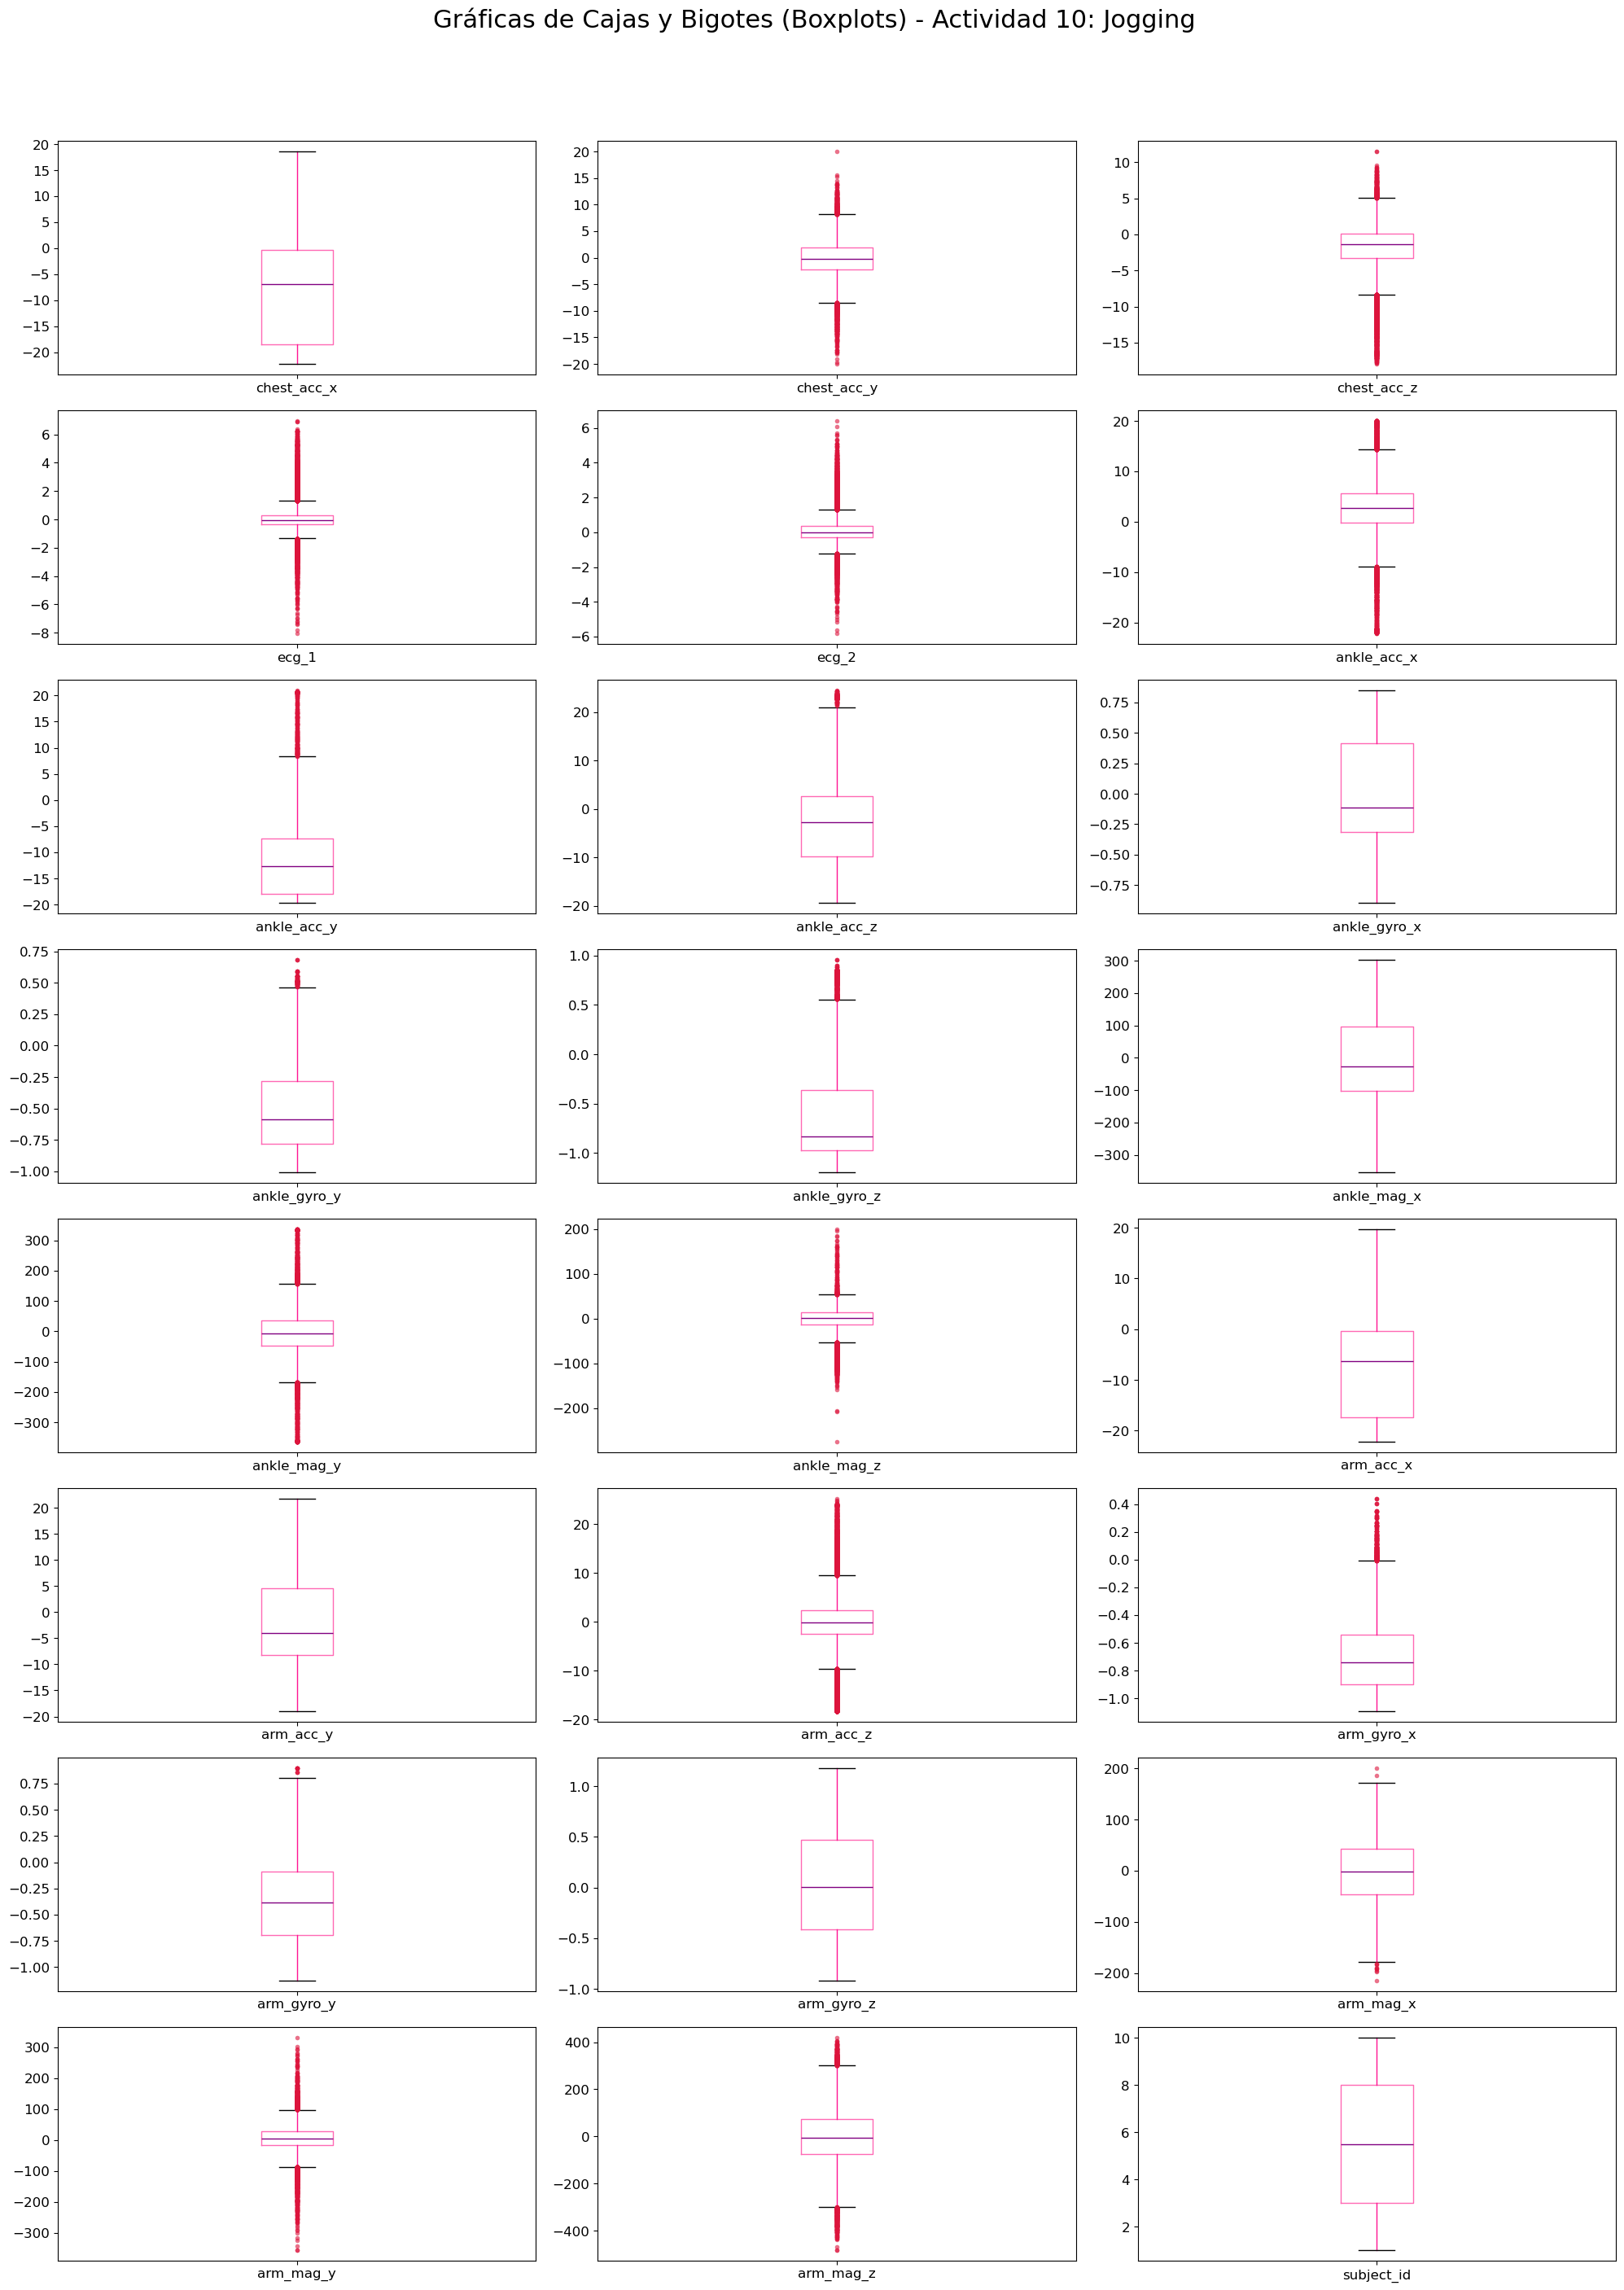

In [10]:
color_props = dict(boxes='hotpink', whiskers='deeppink', medians='purple', caps='black')
puntitos_props = dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.6, markeredgecolor='none')

# Dibujamos el mosaico
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='box', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(20, 50), 
    color=color_props,
    flierprops=puntitos_props,
    fontsize=12      
)


plt.suptitle(f'Gráficas de Cajas y Bigotes (Boxplots) - Actividad {actividad}: {actividades[actividad]}', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Matriz de correlación</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

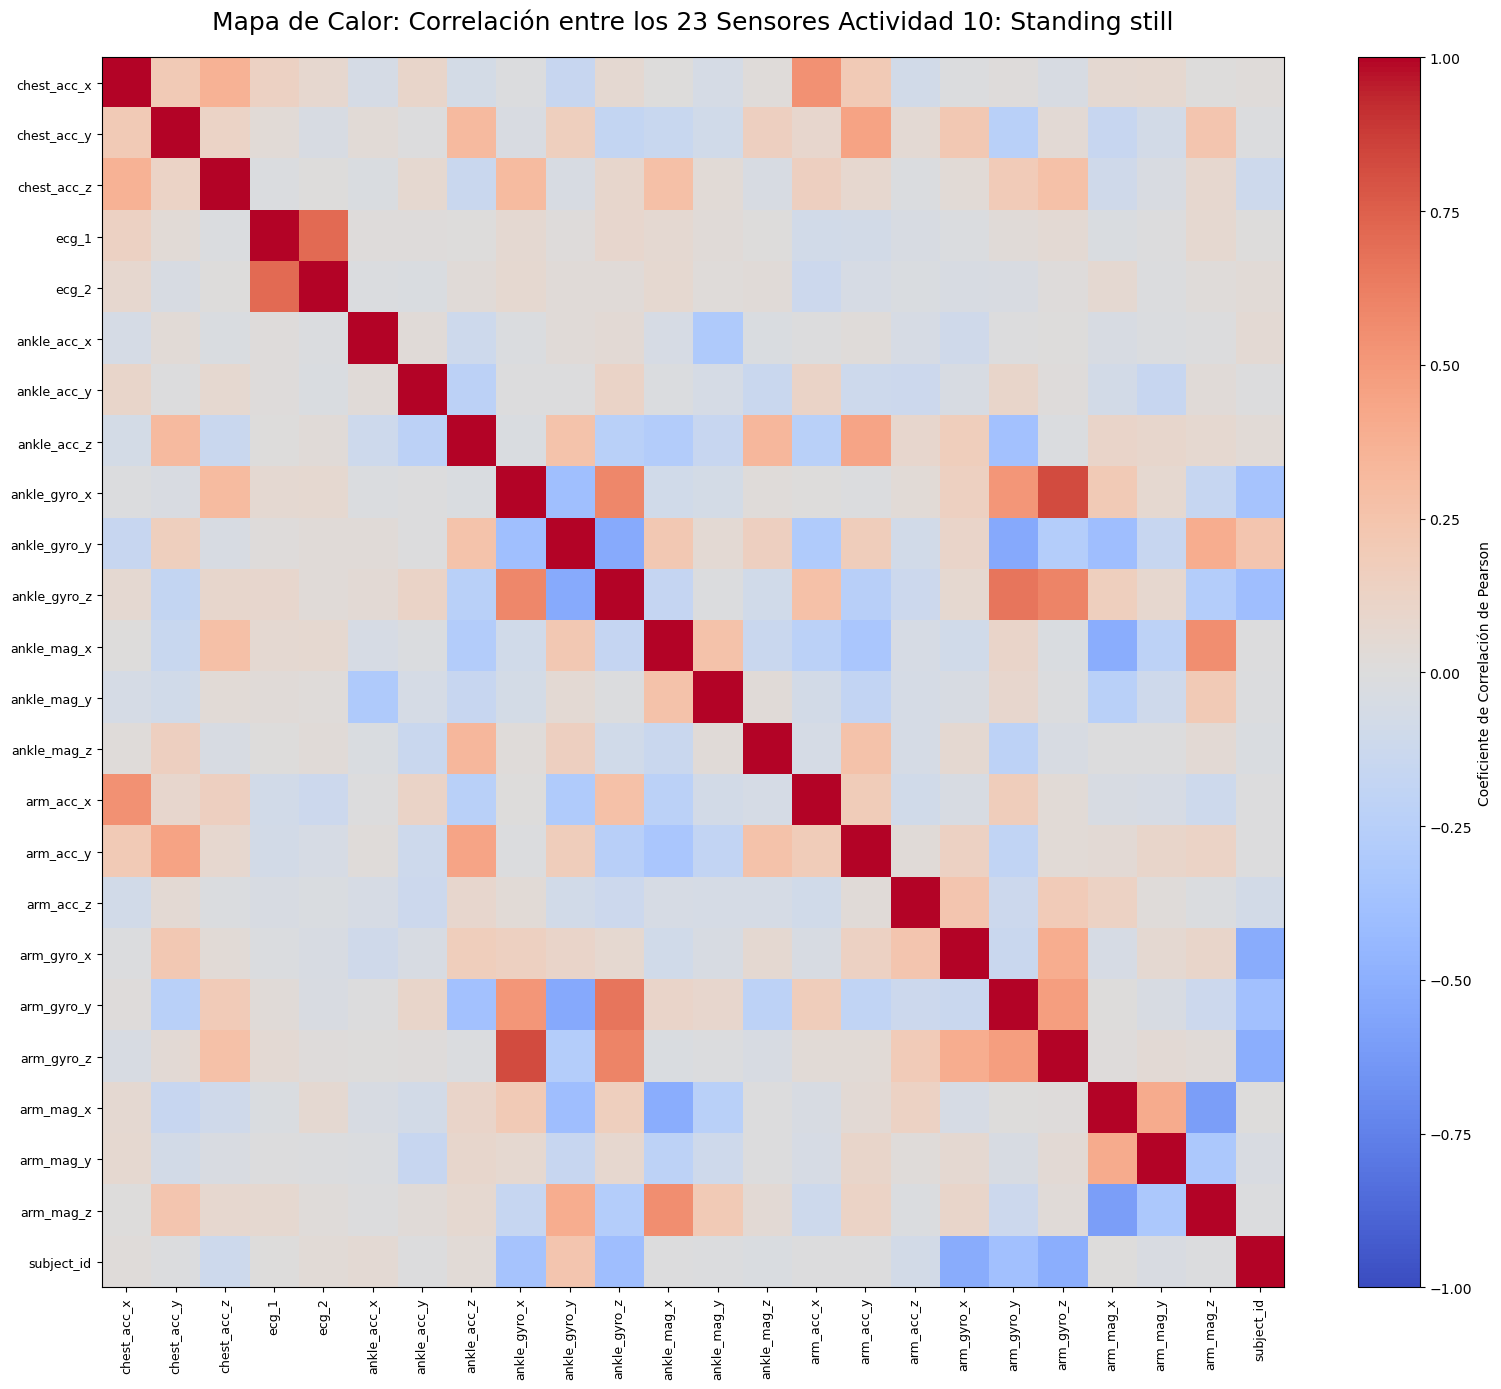

In [11]:
# Calculamos la matriz de correlación de Pearson
matriz_correlacion = DATASET_SENSORES_ACTIVIDAD.corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(16, 14))

# Usamos imshow para dibujar la cuadrícula, coolwarm da rojo a los +1 y azul a los -1
imagen = plt.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Agregamos la barra de colores al lado
plt.colorbar(imagen, label='Coeficiente de Correlación de Pearson')
plt.title(f'Mapa de Calor: Correlación entre los 23 Sensores Actividad {actividad}: {actividades[1]}', fontsize=18, pad=20)

# Ponemos los nombres de las 45 columnas en los bordes
posiciones = np.arange(len(DATASET_SENSORES_ACTIVIDAD.columns))
plt.xticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, rotation=90, fontsize=9)
plt.yticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, fontsize=9)

plt.grid(False) 
plt.tight_layout()

plt.show

<h1>Matriz de dispersión</h1>

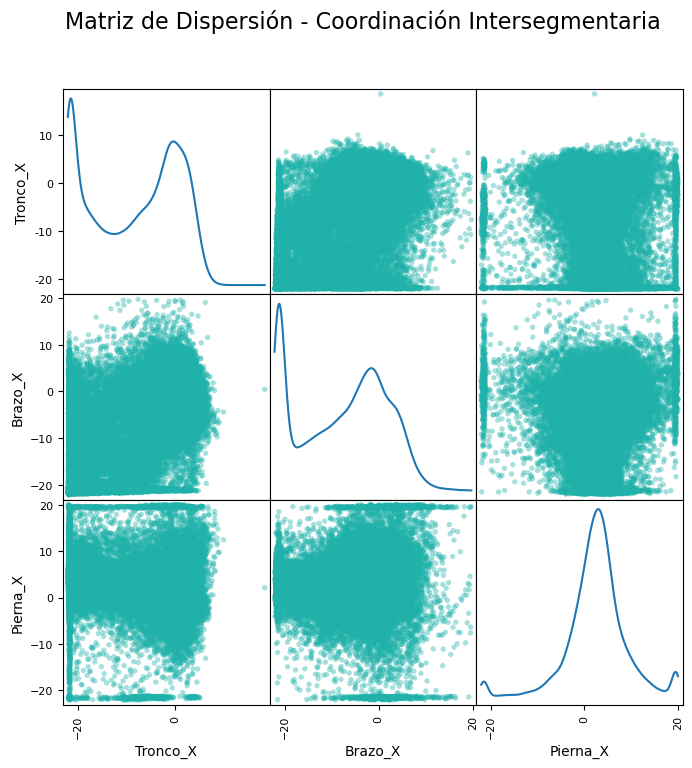

In [12]:
# Selección estratégica: un eje X por segmento corporal
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos].copy()


datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X"
]

pd.plotting.scatter_matrix(
    datos_scatter,
    alpha=0.4,
    figsize=(8, 8),
    diagonal='kde',
    color='lightseagreen',
    marker='o',
    s=15
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria',
    fontsize=16
)

plt.show()

<h1>Matriz de dispersión por sujeto</h1>

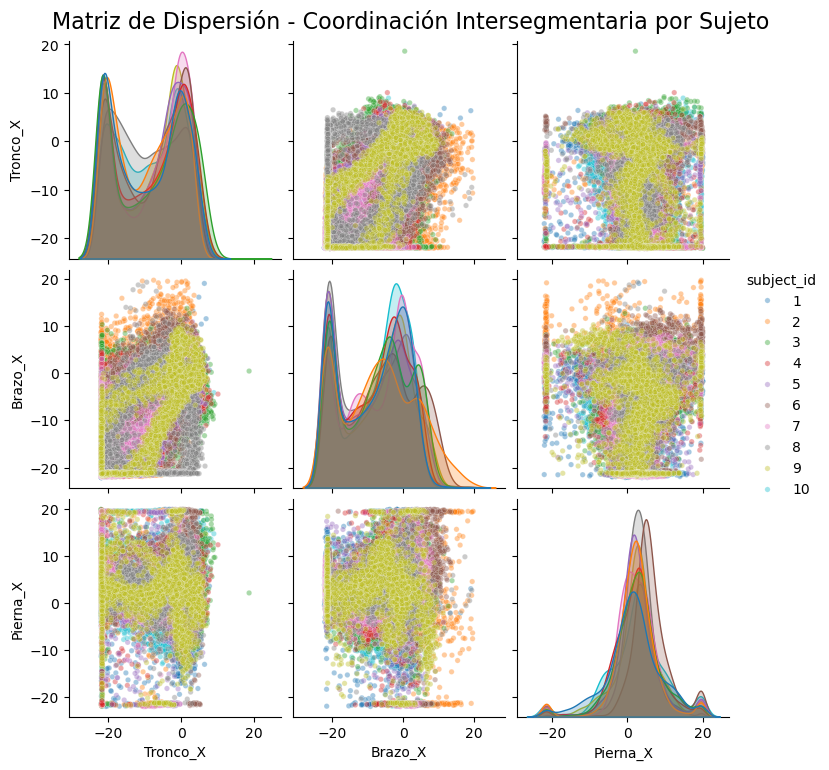

In [13]:
# Selección estratégica
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos + ["subject_id"]].copy()

datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X",
    "subject_id"
]

# Convertir a categoría (importante para que seaborn lo trate como grupo)
datos_scatter["subject_id"] = datos_scatter["subject_id"].astype("category")

# Pairplot con color por sujeto
sns.pairplot(
    datos_scatter,
    vars=["Tronco_X", "Brazo_X", "Pierna_X"],
    hue="subject_id",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria por Sujeto',
    y=1.02,
    fontsize=16
)

plt.show()